## CLUSTERING ANALYSIS 

#### Data Preprocessing:

In [2]:
import pandas as pd

xls = pd.ExcelFile("EastWestAirlines.xlsx")
print(xls.sheet_names)

['Description', 'data']


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

df = df.drop("ID#", axis=1)

df = df.dropna()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

scaler = StandardScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print(scaled_df.head())

    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.438859         0.0  -0.719055        0.0        0.0    -0.783131   
1 -0.647735         0.0  -0.719055        0.0        0.0    -0.780130   
2 -0.128773         0.0  -0.719055        0.0        0.0    -0.494075   
3 -0.752607         0.0  -0.719055        0.0        0.0    -0.759268   
4 -0.714019         0.0  -0.719055        0.0        0.0    -0.795867   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
0    -1.081732          -0.378837        -0.409708           1.503693   
1    -0.952735          -0.378837        -0.409708           1.488035   
2    -0.694742          -0.378837        -0.409708           1.520330   
3    -1.081732          -0.378837        -0.409708           1.480206   
4    -1.210728          -0.378837        -0.409708           1.475312   

     Award?  
0 -0.623072  
1 -0.623072  
2 -0.623072  
3 -0.623072  
4 -0.623072  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2875 entries, 0 to 2874
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Balance            2875 non-null   float64
 1   Qual_miles         2875 non-null   float64
 2   cc1_miles          2875 non-null   float64
 3   cc2_miles          2875 non-null   float64
 4   cc3_miles          2875 non-null   float64
 5   Bonus_miles        2875 non-null   float64
 6   Bonus_trans        2875 non-null   float64
 7   Flight_miles_12mo  2875 non-null   float64
 8   Flight_trans_12    2875 non-null   float64
 9   Days_since_enroll  2875 non-null   float64
 10  Award?             2875 non-null   float64
dtypes: float64(11)
memory usage: 247.2 KB
None
            Balance  Qual_miles     cc1_miles  cc2_miles  cc3_miles  \
count  2.875000e+03      2875.0  2.875000e+03     2875.0     2875.0   
mean  -7.908650e-17         0.0 -7.908650e-17        0.0        0.0   
std    1

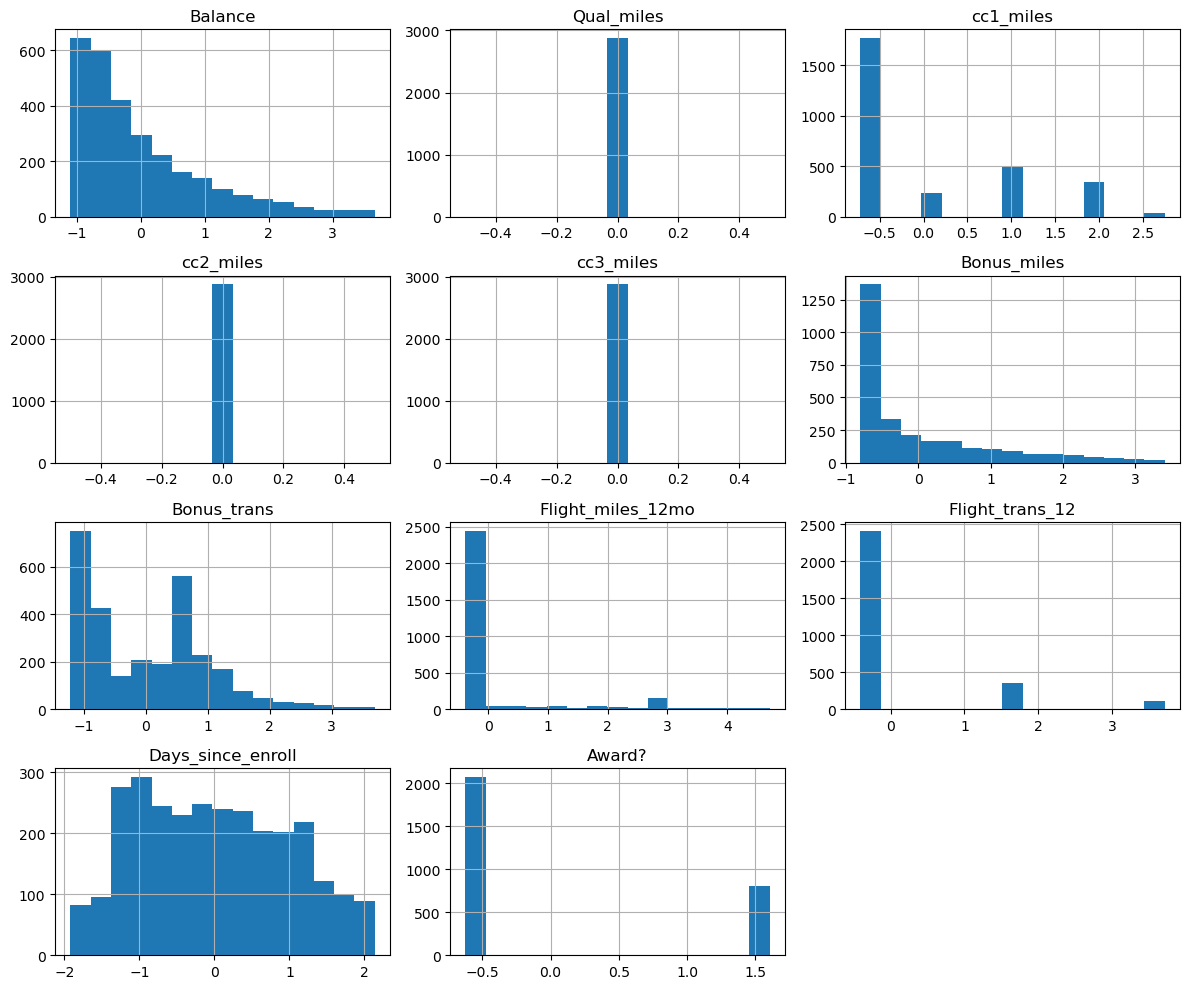

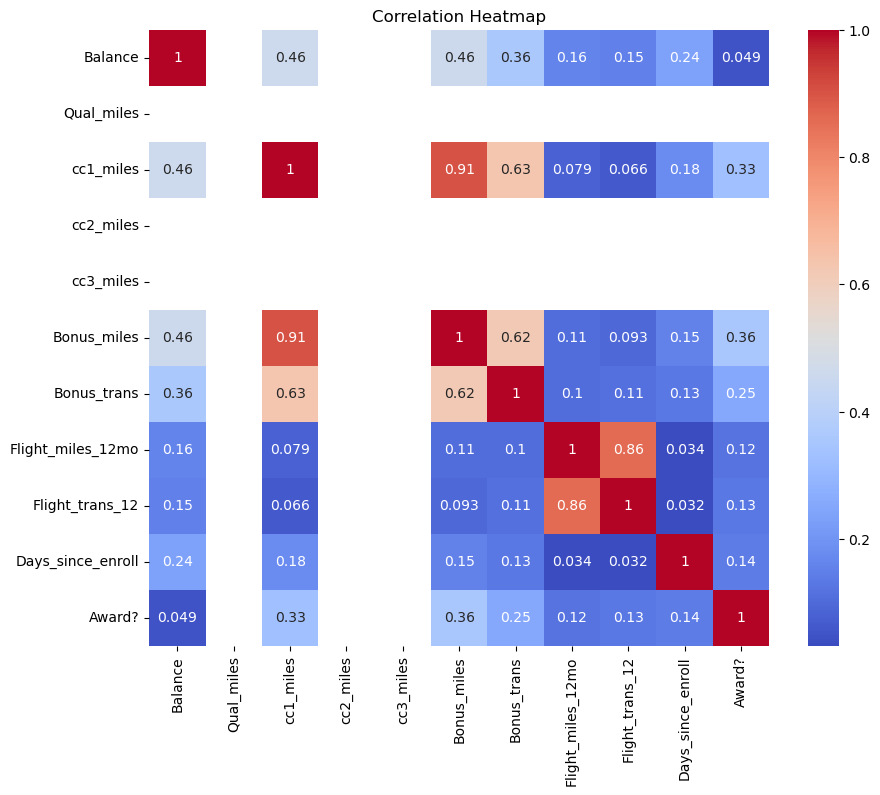

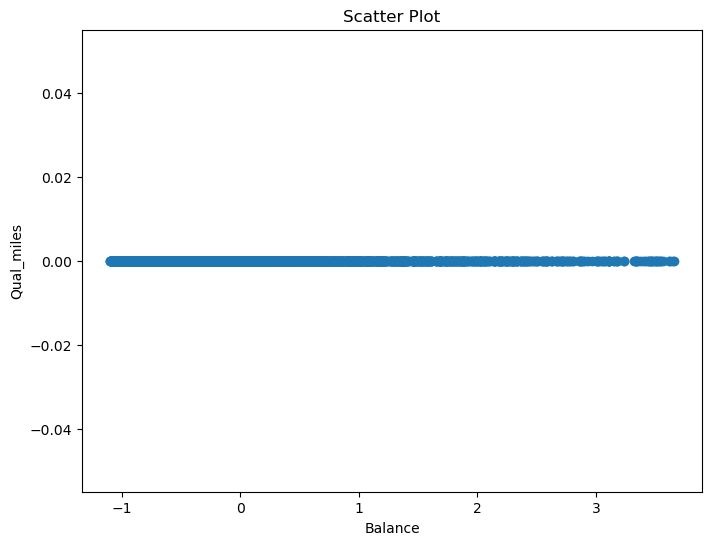

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print(scaled_df.info())
print(scaled_df.describe())

scaled_df.hist(figsize=(12, 10), bins=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(scaled_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1])
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.title("Scatter Plot")
plt.show()

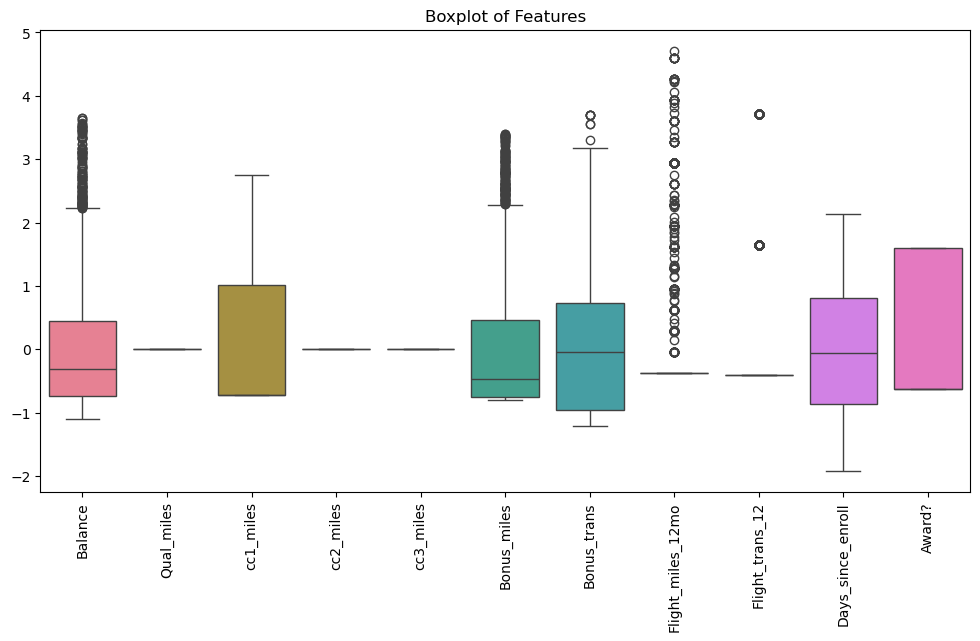

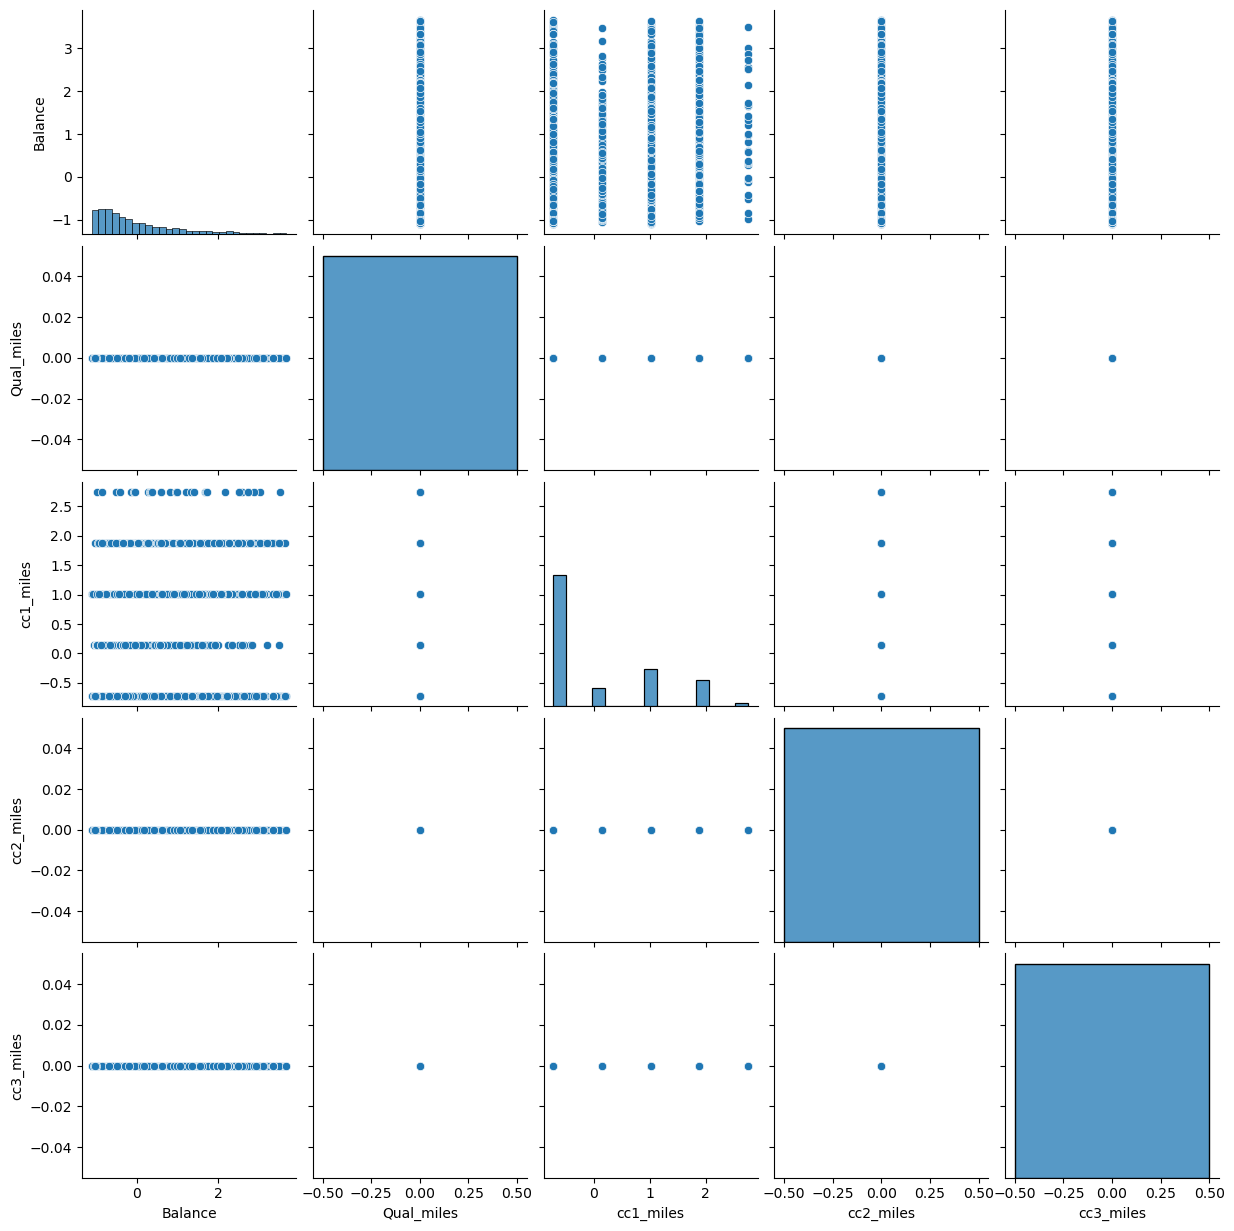

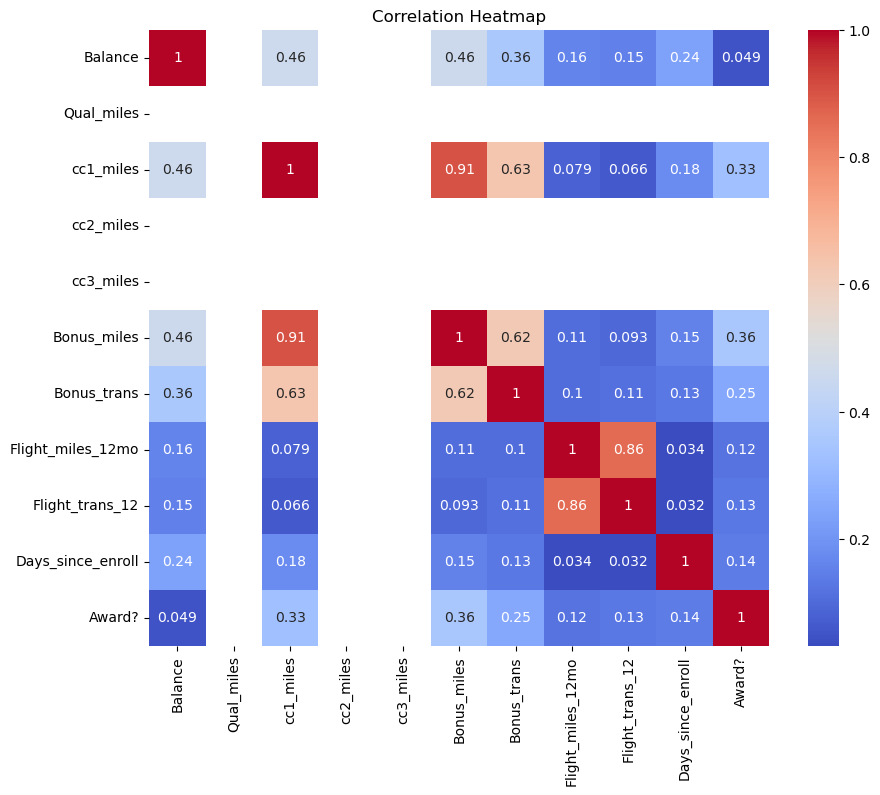

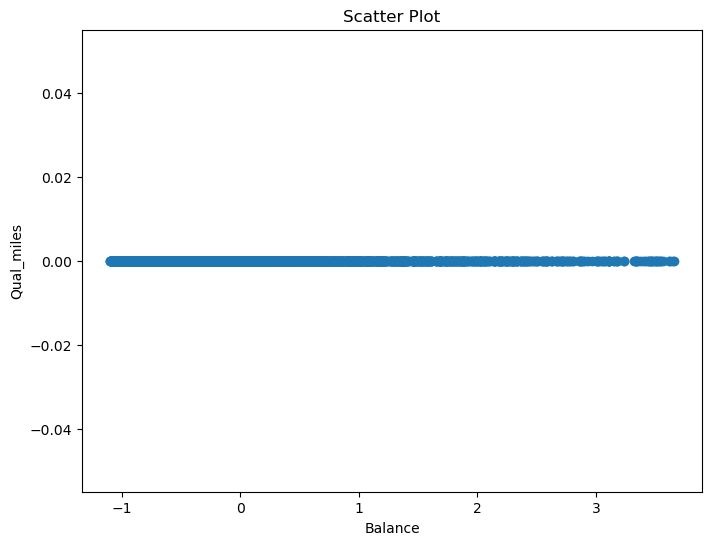

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=scaled_df)
plt.title("Boxplot of Features")
plt.xticks(rotation=90)
plt.show()

sns.pairplot(scaled_df.iloc[:, :5])   # First 5 features
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(scaled_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1])
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.title("Scatter Plot")
plt.show()

#### Implementing Clustering Algorithms:

In [11]:
from sklearn.cluster import KMeans, DBSCAN

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df["KMeans_Cluster"] = kmeans_labels

print(scaled_df.head())

dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(scaled_df.iloc[:, :-1])

scaled_df["DBSCAN_Cluster"] = dbscan_labels

print(scaled_df.head())

    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.438859         0.0  -0.719055        0.0        0.0    -0.783131   
1 -0.647735         0.0  -0.719055        0.0        0.0    -0.780130   
2 -0.128773         0.0  -0.719055        0.0        0.0    -0.494075   
3 -0.752607         0.0  -0.719055        0.0        0.0    -0.759268   
4 -0.714019         0.0  -0.719055        0.0        0.0    -0.795867   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
0    -1.081732          -0.378837        -0.409708           1.503693   
1    -0.952735          -0.378837        -0.409708           1.488035   
2    -0.694742          -0.378837        -0.409708           1.520330   
3    -1.081732          -0.378837        -0.409708           1.480206   
4    -1.210728          -0.378837        -0.409708           1.475312   

     Award?  KMeans_Cluster  
0 -0.623072               1  
1 -0.623072               1  
2 -0.623072               1  
3 

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
scaled_df["KMeans_Cluster"] = kmeans.fit_predict(scaled_df)

print("K-Means Clusters:")
print(scaled_df["KMeans_Cluster"].value_counts())

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
scaled_df["DBSCAN_Cluster"] = dbscan.fit_predict(scaled_df.drop("KMeans_Cluster", axis=1))

print("\nDBSCAN Clusters:")
print(scaled_df["DBSCAN_Cluster"].value_counts())

K-Means Clusters:
KMeans_Cluster
1    1582
2     891
0     402
Name: count, dtype: int64

DBSCAN Clusters:
DBSCAN_Cluster
 0    1805
 2     602
 3     180
 1     124
-1     115
 4      37
 5       7
 6       5
Name: count, dtype: int64


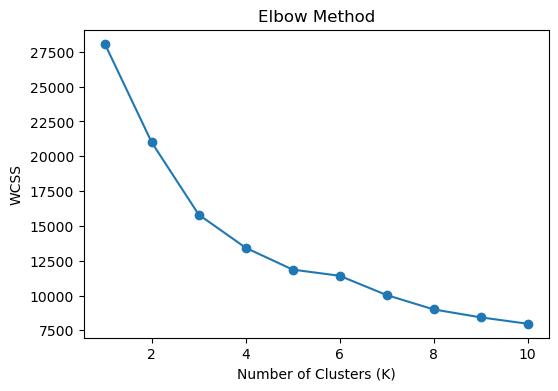

eps = 0.5, min_samples = 5
Clusters: 19
Noise Points: 1139

eps = 1.0, min_samples = 5
Clusters: 16
Noise Points: 419

eps = 1.5, min_samples = 5
Clusters: 10
Noise Points: 126

eps = 2.0, min_samples = 5
Clusters: 12
Noise Points: 85



In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

parameters = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 5),
    (2.0, 5)
]

for eps, min_pts in parameters:
    dbscan = DBSCAN(eps=eps, min_samples=min_pts)
    labels = dbscan.fit_predict(scaled_df)

    print(f"eps = {eps}, min_samples = {min_pts}")
    print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
    print("Noise Points:", list(labels).count(-1))
    print()

#### Cluster Analysis and Interpretation:

In [14]:
print("K-Means Cluster Counts:")
print(scaled_df["KMeans_Cluster"].value_counts())

print("\nMean values of each K-Means cluster:")
print(scaled_df.groupby("KMeans_Cluster").mean())

print("\nDBSCAN Cluster Counts:")
print(scaled_df["DBSCAN_Cluster"].value_counts())

print("\nMean values of each DBSCAN cluster:")
print(scaled_df.groupby("DBSCAN_Cluster").mean())

K-Means Cluster Counts:
KMeans_Cluster
1    1582
2     891
0     402
Name: count, dtype: int64

Mean values of each K-Means cluster:
                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                          
0               0.358067         0.0   0.099951        0.0        0.0   
1              -0.434667         0.0  -0.660453        0.0        0.0   
2               0.610213         0.0   1.127561        0.0        0.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                 
0                  0.166046     0.207271           2.232532         2.212522   
1                 -0.604390    -0.531254          -0.374441        -0.390148   
2                  0.998198     0.849742          -0.342438        -0.305521   

                Days_since_enroll    Award?  DBSCAN_Cluster  
KMeans_Cluster                        

#### Visualization:

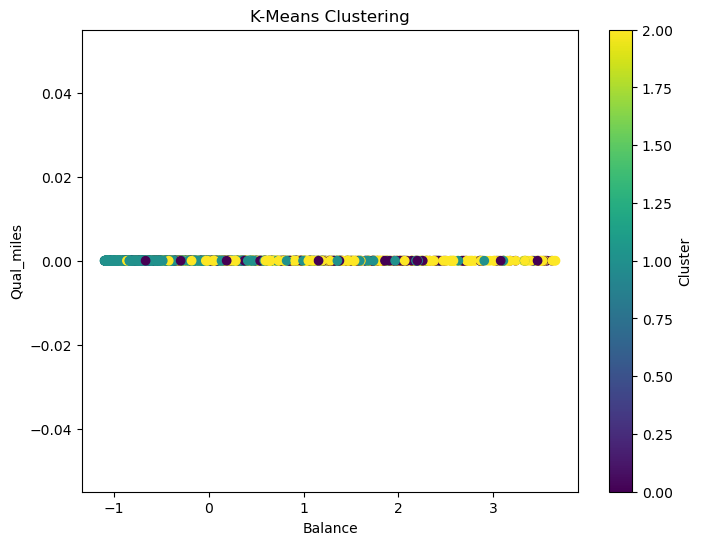

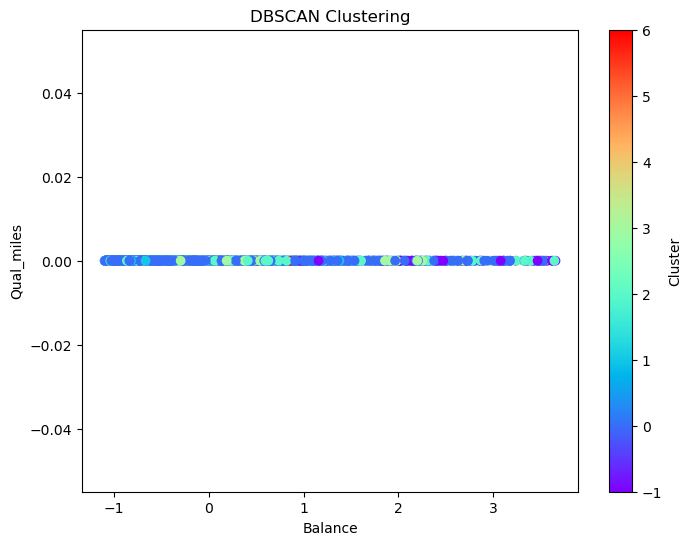

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1],
            c=scaled_df["KMeans_Cluster"], cmap="viridis")
plt.title("K-Means Clustering")
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.colorbar(label="Cluster")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1],
            c=scaled_df["DBSCAN_Cluster"], cmap="rainbow")
plt.title("DBSCAN Clustering")
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.colorbar(label="Cluster")
plt.show()

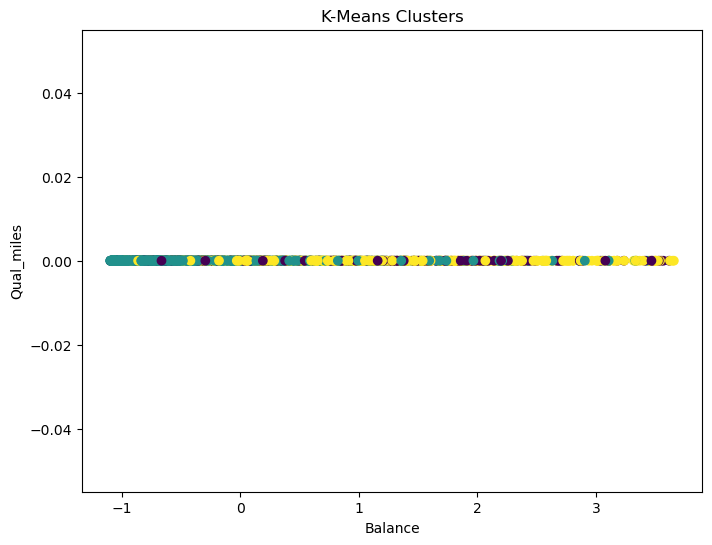

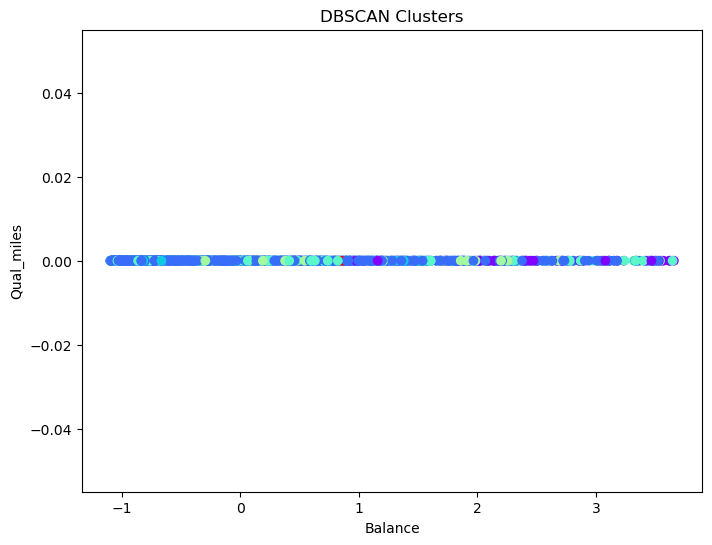

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    scaled_df.iloc[:, 0],
    scaled_df.iloc[:, 1],
    c=scaled_df["KMeans_Cluster"],
    cmap="viridis"
)

plt.title("K-Means Clusters")
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    scaled_df.iloc[:, 0],
    scaled_df.iloc[:, 1],
    c=scaled_df["DBSCAN_Cluster"],
    cmap="rainbow"
)

plt.title("DBSCAN Clusters")
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])
plt.show()

#### Evaluation and Performance Metrics:

In [17]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    scaled_df.drop(["KMeans_Cluster", "DBSCAN_Cluster"], axis=1),
    scaled_df["KMeans_Cluster"]
)

print("K-Means Silhouette Score:", kmeans_score)

dbscan_data = scaled_df[scaled_df["DBSCAN_Cluster"] != -1]

if dbscan_data["DBSCAN_Cluster"].nunique() > 1:
    dbscan_score = silhouette_score(
        dbscan_data.drop(["KMeans_Cluster", "DBSCAN_Cluster"], axis=1),
        dbscan_data["DBSCAN_Cluster"]
    )
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN Silhouette Score cannot be calculated (only one cluster found).")

K-Means Silhouette Score: 0.3372892908033959
DBSCAN Silhouette Score: 0.2673349072078038
